# Pré-Processamento - Bases para Aprendizagem de Máquina

**Descrição:** Pipeline rigoroso **sem data leakage**, seguindo a metodologia da tese (seção 4.4.2).

## Princípio anti-leakage
```
RAW DATA
   │
   ├─ train_test_split (estratificado, random_state=0, 80/20)
   │        │                    │
   │     TREINO               TESTE
   │     (80%)                (20%)
   │       │                    │
   │  fit LOF                   │
   │  remove outliers           │  ← teste nunca visto
   │       │                    │
   │  fit Encoders → transform treino e teste
   │       │                    │
   │  fit MinMaxScaler → transform treino e teste
   │       │                    │
   └──► salvar train / test  ◄──┘
```
O cross-validation (StratifiedKFold) será aplicado **dentro do treino** nos experimentos de ML.

## Experimentos
- **Seção 3** – Base SEM RIN (17 atributos brutos → 23 após encoding)
- **Seção 4** – Base COM RIN (30 atributos brutos → 37 após encoding)


**Autor:** Joyce Ribeiro Xavier, Ana Carolina de Sousa Camilo e Ruan Campello  
**Data:** 10/06/2026

---
## Índice
1. [Configurações e importações](#scrollTo=907d2ea9)
2. [Carga de dados e remoção de leakage](#scrollTo=e48572ed)
3. [Experimento 1 – Base SEM RIN](#scrollTo=3BZJTLxRAdAF&line=3&uniqifier=1)
   - 3.1 [Seleção de colunas e Split treino / teste](#scrollTo=a6031930&line=2&uniqifier=1)
   - 3.2 [Remoção de Outliers com LocalOutlierFactor](#scrollTo=ecb84253&line=2&uniqifier=1)
   - 3.3 [Encoding de Atributos Categóricos](#scrollTo=299b0808&line=1&uniqifier=1)
   - 3.4 [Imputação de Valores Ausentes](#scrollTo=1a698923&line=1&uniqifier=1)
   - 3.5 [Normalização com MinMaxScaler](#scrollTo=91a0aee7&line=1&uniqifier=1)
   - 3.6 [EDA Rápida – Base SEM RIN](#scrollTo=cb9df635&line=1&uniqifier=1)
   - 3.7 [Exportação – Base SEM RIN](#scrollTo=eb685cbe&line=1&uniqifier=1)


4. [Experimento 2 - Base COM RIN](#scrollTo=261e7fe7)
   - 4.1 [Seleção de colunas e Split treino / teste](#scrollTo=88c142d8)
   - 4.2 [Remoção de Outliers com LocalOutlierFactor](#scrollTo=d8d71591)
   - 4.3 [Encoding de Atributos Categóricos](#scrollTo=f3a8c7a7)
   - 4.4 [Imputação de Valores Ausentes](#scrollTo=31507445)
   - 4.5 [Normalização com MinMaxScaler](#scrollTo=9ff453ef)
   - 4.6 [EDA Rápida – Base COM RIN](#scrollTo=fc6a293b)
   - 4.7 [Exportação – Base COM RIN](#scrollTo=f36ae45e)
5. [Resumo Geral e Guia para Cross-Validation](#scrollTo=0387d4fa&line=1&uniqifier=1)

# 1. Configurações e Importações

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -q category_encoders

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 90000)
sns.set_theme(style='whitegrid')

ROTULO     = 'Deleteria11'
SEED       = 0          # random_state conforme tese
TEST_SIZE  = 0.2
OUTPUT_DIR = '/content/drive/MyDrive/Bioinfo/Bases'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Imports OK')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.9 MB/s eta 0:00:00
Imports OK


# 2. Carga dos Dados e Remoção de Leakage

Nesta etapa, realizamos o carregamento da base de dados e aplicamos o primeiro filtro crítico de pré-processamento: a **remoção de *data leakage* (vazamento de dados)**.

### Por que remover esses atributos?


> Todos os atributos que fazem parte (direta e
indiretamente) da construção do rótulo `Deleteria11`, ou seja, os atributos:
**dbNSFP_SIFT_pred**, **PolyPhen2_Dam_pred**, **dbNSFP_PROVEAN_pred**,
**dbNSFP_gnomAD_exomes_AF**, os outros 19 preditores, **NdamageCalc**, **COMMON**,
**dbNSFP_ExAC_AF** e **Ndamage** foram excluídos, pois essa base não pode conter atributos
relacionados aos rótulos para não gerar viés no treinamento da aprendizagem. Além desses,
todos os outros atributos que não possuem informações importantes (a maioria códigos de
identificação, informações que estão fora do escopo do domínio do problema), os atributos
com valores únicos em todas as instâncias, os atributos redundantes, ou os que possuem todas
as suas instâncias com valores zeros (não válidos), também foram descartados e estão
elencados na **Tabela 14**. Após a retirada de todos esses atributos foi verificado se não foram?
gerados registros duplicados na base, para não causar ruídos (enviesamento de dados) no
processo de aprendizagem de máquina e comprometer os resultado




In [ ]:
CAMINHO_CSV = '/content/drive/MyDrive/Bioinfo/Base_33Tecidos_cleancomDeleteria11(1).csv'

df_raw = pd.read_csv(CAMINHO_CSV, sep='\t', low_memory=False)
print(f'Shape original: {df_raw.shape}')

df_raw = df_raw[df_raw['Tecido'] == 'BRCA'].copy()
print(f'Registros após filtro BRCA: {df_raw.shape[0]:,}')


Shape original: (26893, 94)
Registros após filtro BRCA: 950


In [ ]:
# ── Colunas que DEVEM permanecer em cada base ─────────────────────────────────
COLUNAS_SEM_RIN = [
    'CHROM', 'REF', 'ALT',
    'VariantEffect_EFF', 'Gene_EFF', 'Exon_EFF',
    'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF',
    'aminBefore', 'aminAfter', 'poschangeProt',
    'Deleteria11', 'Blosum62', 'groupChange',
    'essencialChange', 'substitution', 'Tecido',
]

COLUNAS_COM_RIN = [
    'CHROM', 'REF', 'ALT',
    'VariantEffect_EFF', 'Gene_EFF', 'Exon_EFF',
    'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF',
    'aminBefore', 'aminAfter', 'poschangeProt',
    'Deleteria11', 'Blosum62', 'groupChange',
    'essencialChange', 'substitution',
    'Degree_RING', 'Bfactor_CA_RING',
    'triangles_node', 'clusteringCoef_node', 'betweennessWeighted_node',
    'Inter_Lig_tot', 'Inter_Res_tot',
    'Inter_IAC_Lig_tot', 'Inter_VDW_Lig_tot', 'Inter_VDW_Res_tot',
    'Inter_HBOND_Res_tot', 'Inter_PIPISTACK_Res_tot',
    'Inter_IONIC_Res_tot', 'Inter_PICATION_Res_tot',
    'Tecido',
]

COLUNAS_PROTEGIDAS = set(COLUNAS_SEM_RIN) | set(COLUNAS_COM_RIN)

# ── Colunas a remover (leakage) ───────────────────────────────────────────────
preditores_rotulo = [
    'dbNSFP_SIFT_pred','PolyPhen2_Dam_pred','dbNSFP_PROVEAN_pred',
    'dbNSFP_gnomAD_exomes_AF','dbNSFP_ExAC_AF',
    'dbNSFP_DEOGEN2_pred','dbNSFP_MetaSVM_pred','dbNSFP_fathmmMKL_coding_pred',
    'dbNSFP_PrimateAI_pred','dbNSFP_MCAP_pred','dbNSFP_ClinPred_pred',
    'dbNSFP_BayesDel_addAF_pred','dbNSFP_Polyphen2_HVAR_pred',
    'dbNSFP_FATHMM_pred','dbNSFP_SIFT4G_pred','dbNSFP_LRT_pred',
    'dbNSFP_fathmmXF_coding_pred','dbNSFP_BayesDel_noAF_pred',
    'dbNSFP_Aloft_pred','dbNSFP_MutationTaster_pred',
    'dbNSFP_MetaLR_pred','dbNSFP_LISTS2_pred',
    'dbNSFP_Polyphen2_HDIV_pred','dbNSFP_MutationAssessor_pred',
]
campos_derivados = ['NdamageCalc','Ndamage','COMMON','Deleteria','Deleteria5','Deleteria10']
tabela14 = [
    'POS','Interpro_domain','RefSeq_EFF','SNP_ID_COMMON',
    'Uniprot_id','PDB_id','Swiss-Prot','db_name','NodeId_RING',
    'Tipo_Mut_EFF','Risco_Mut_EFF','typechangecDNA_EFF','typechangeProt',
    'Point_Mutation_EFF','changeProt_EFF','changecDNA_EFF',
    'Resolution','db_align_beg','db_align_end',
    'pdbx_auth_seq_align_beg','pdbx_auth_seq_align_end','pdbx_strand_id',
    'seq_align_beg','seq_align_end','pdbx_align_begin',
    'pdbx_seq_one_letter_code','len_seq',
    'groupBefore','groupAfter','aminBeforeEssential','aminAfterEssential',
    'Dssp_RING',
    'Inter_HBOND_Lig_tot','Inter_PIPISTACK_Lig_tot',
    'Inter_IONIC_Lig_tot','Inter_SSBOND_Lig_tot','Inter_PICATION_Lig_tot',
    'Inter_IAC_Res_tot','Inter_SSBOND_Res_tot',
]

todos_remover  = list(set(preditores_rotulo + campos_derivados + tabela14))
remover_seguro = [c for c in todos_remover
                  if c in df_raw.columns and c not in COLUNAS_PROTEGIDAS]


df_clean = df_raw.drop(columns=remover_seguro)
print(f'Shape original : {df_raw.shape}')
print(f'Shape limpo    : {df_clean.shape}')
# Remoção dos valores "-" da coluna Blosum62
df_clean = df_clean[df_clean['Blosum62'] != '-' ]

# Transformação da coluna Blosum62 para uma coluna numérica
df_clean['Blosum62'] = pd.to_numeric(df_clean['Blosum62'])

# Verificar duplicados
n_dupes = df_clean.duplicated().sum()
if n_dupes > 0:
    df_clean = df_clean.drop_duplicates(keep='first')
    print(f'Duplicados removidos: {n_dupes}  → shape: {df_clean.shape}')
else:
    print('Nenhum duplicado encontrado.')


Shape original : (950, 94)
Shape limpo    : (950, 31)
Nenhum duplicado encontrado.


## 3. Experimento 1 – Base SEM RIN

Nesta seção, executamos o **Experimento 1**, utilizando a base de dados configurada como **SEM RIN**. O objetivo é aplicar o pipeline de pré-processamento padronizado para transformar os dados brutos em uma matriz pronta para os algoritmos de Aprendizagem de Máquina, resultando na expansão de **17 atributos brutos para 23 atributos finais**, conforme detalhado na **Seção 4.4.2 da Tese**.

---

### Rigor Metodológico contra Data Leakage
> **Observação:** O particionamento dos dados (Split Treino/Teste) é realizado logo no **Passo 2**, *antes de qualquer transformação estrutural* (como imputação, encoding ou normalização).
>

---

### Etapas do Pipeline

1. **Seleção de Colunas & Eliminação de Nulos (`dropna`):**
   Filtramos as variáveis de interesse estabelecidas no escopo metodológico e removemos registros com valores ausentes críticos antes da divisão.

   **Divisão dos Dados (Train/Test Split):**
   * **Proporção:** 80% para treinamento e 20% para teste.
   * **Estratégia:** Amostragem estratificada (garante que a proporção da variável alvo seja idêntica em ambas as partições).
   * **Reprodutibilidade:** Fixado com `seed=0` para garantir que os mesmos registros caiam nas mesmas partições em qualquer execução.

2. **Tratamento de Outliers com LOF (Local Outlier Factor):**
   * **Aplicação exclusiva no Treino:** O algoritmo calcula a densidade local de cada ponto em relação aos seus vizinhos. Os registros identificados como anomalias severas são removidos para evitar que o modelo aprenda padrões ruidosos. O teste permanece intacto para simular o mundo real.

3. **Codificação de Variáveis Categóricas (Categorical Encoding):**
   A expansão do dataset (de 17 para 23 colunas) ocorre nesta etapa devido à binarização e vetorização das variáveis qualitativas:

   * **Frequency Encoding:** Substitui as categorias de maior cardinalidade pela sua frequência relativa observada no treino.
   * fit no treino, transform em treino e teste

   * **One-Hot Encoding:** Cria variáveis dummy binárias para atributos categóricos nominais, expandindo o espaço vetorial.
   * fit no treino, transform em treino e teste


4. **Imputação de Valores Ausentes pela Mediana:**
   * Caso existam dados faltantes residuais, eles são preenchidos utilizando a **mediana** calculada sobre o conjunto de treino. A mediana é escolhida por ser uma métrica robusta à presença de eventuais outliers remanescentes.
    * fit no treino, transform em treino e teste


5. **Normalização dos Dados (MinMaxScaler):**
   * Redimensiona os recursos numéricos para a escala $[0, 1]$. Essa etapa é matemática e biologicamente fundamental para garantir que variáveis com magnitudes numéricas discrepantes não distorçam o cálculo de distância ou gradiente dos algoritmos.
    * fit no treino, transform em treino e teste

   
   $$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

6. **EDA Rápida - Base SEM RIN**: Para a vizualização dos dados.


7. **Exportação:**
   * Salvamento e persistência das matrizes finais prontas (`X_train`, `X_test`, `y_train`, `y_test`) para a alimentação dos modelos de classificação/regressão.

## 3.1 Seleção de colunas e Split treino / teste

In [ ]:
cols_sem   = [c for c in COLUNAS_SEM_RIN if c in df_clean.columns]
df_sem_rin = df_clean[cols_sem].dropna(subset=[ROTULO]).copy()

print(f'Base sem RIN: {df_sem_rin.shape}')
print(f'Distribuição do rótulo:\n{df_sem_rin[ROTULO].value_counts()}')


Base sem RIN: (891, 17)
Distribuição do rótulo:
Deleteria11
1    464
0    427
Name: count, dtype: int64


In [ ]:
train_sem, test_sem = train_test_split(
    df_sem_rin,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df_sem_rin[ROTULO]
)

print('─' * 50)
print(f'Treino : {train_sem.shape}  (esperado: ~20.090 x 17)')
print(f'Teste  : {test_sem.shape}   (esperado:  5.023 x 17)')
print()
print('Distribuição do rótulo no treino:')
print(train_sem[ROTULO].value_counts(normalize=True).round(4))
print('Distribuição do rótulo no teste:')
print(test_sem[ROTULO].value_counts(normalize=True).round(4))


──────────────────────────────────────────────────
Treino : (712, 17)  (esperado: ~20.090 x 17)
Teste  : (179, 17)   (esperado:  5.023 x 17)

Distribuição do rótulo no treino:
Deleteria11
1    0.5211
0    0.4789
Name: proportion, dtype: float64
Distribuição do rótulo no teste:
Deleteria11
1    0.5196
0    0.4804
Name: proportion, dtype: float64


In [ ]:
# Separar X e y
X_train_sem = train_sem.drop(columns=[ROTULO]).copy()
y_train_sem = train_sem[ROTULO].copy()
X_test_sem  = test_sem.drop(columns=[ROTULO]).copy()
y_test_sem  = test_sem[ROTULO].copy()


## 3.2 Remoção de Outliers com LocalOutlierFactor

`fit_predict` aplicado **apenas no treino** para evitar leakage.


In [ ]:
num_cols_sem = X_train_sem.select_dtypes(include=[np.number]).columns.tolist()
print(f'Colunas numéricas usadas no LOF ({len(num_cols_sem)}): {num_cols_sem}')

# Preenche NaN apenas para o LOF (mediana do treino)
X_train_sem_num = X_train_sem[num_cols_sem].fillna(
    X_train_sem[num_cols_sem].median()
)
# mostrar os valores inputados


lof_sem  = LocalOutlierFactor(n_neighbors=20, contamination='auto')
pred_sem = lof_sem.fit_predict(X_train_sem_num)   # -1 = outlier

mask_sem = pred_sem == 1
X_train_sem = X_train_sem[mask_sem].copy()
y_train_sem = y_train_sem[mask_sem].copy()

print(f'\nTreino original  : {train_sem.shape[0]:,} registros')
print(f'Treino após LOF  : {X_train_sem.shape[0]:,} registros')
print(f'Outliers removidos: {(~mask_sem).sum():,}  (esperado: ~47, conforme tese)')
print(f'Teste inalterado  : {X_test_sem.shape[0]:,} registros')


Colunas numéricas usadas no LOF (7): ['CHROM', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF', 'poschangeProt', 'Blosum62', 'substitution']

Treino original  : 712 registros
Treino após LOF  : 708 registros
Outliers removidos: 4  (esperado: ~47, conforme tese)
Teste inalterado  : 179 registros


## 3.3 Encoding de Atributos Categóricos

- **Frequency Encoding** (category_encoders) – alta cardinalidade: `Gene_EFF`, `aminBefore`, `aminAfter`, `groupChange`, `Tecido`
- **One-Hot Encoding** (sklearn, drop='first') – baixa cardinalidade: `REF`, `ALT`, `VariantEffect_EFF`, `essencialChange`

`fit` somente no treino; `transform` em treino e teste.


In [ ]:
HIGH_CARD = ['Gene_EFF', 'aminBefore', 'aminAfter', 'groupChange', 'Tecido']
LOW_CARD  = ['REF', 'ALT', 'VariantEffect_EFF', 'essencialChange']

high_card_sem = [c for c in HIGH_CARD if c in X_train_sem.columns]
low_card_sem  = [c for c in LOW_CARD  if c in X_train_sem.columns]
print('Frequency Encoding:', high_card_sem)
print('One-Hot Encoding   :', low_card_sem)


Frequency Encoding: ['Gene_EFF', 'aminBefore', 'aminAfter', 'groupChange', 'Tecido']
One-Hot Encoding   : ['REF', 'ALT', 'VariantEffect_EFF', 'essencialChange']


In [ ]:
# ── Frequency Encoding ───────────────────────────────────────────────────────
freq_enc_sem = ce.CountEncoder(cols=high_card_sem, normalize=True)
freq_enc_sem.fit(X_train_sem[high_card_sem])                        # fit: só treino

X_train_sem[high_card_sem] = freq_enc_sem.transform(X_train_sem[high_card_sem])
X_test_sem[high_card_sem]  = freq_enc_sem.transform(X_test_sem[high_card_sem])

rename_sem = {c: f'{c}_encoded' for c in high_card_sem}
X_train_sem.rename(columns=rename_sem, inplace=True)
X_test_sem.rename(columns=rename_sem,  inplace=True)

# ── One-Hot Encoding ─────────────────────────────────────────────────────────
ohe_sem = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
ohe_sem.fit(X_train_sem[low_card_sem])                              # fit: só treino

ohe_cols_sem = ohe_sem.get_feature_names_out(low_card_sem)
X_train_sem[ohe_cols_sem] = ohe_sem.transform(X_train_sem[low_card_sem])
X_test_sem[ohe_cols_sem]  = ohe_sem.transform(X_test_sem[low_card_sem])

X_train_sem.drop(columns=low_card_sem, inplace=True)
X_test_sem.drop(columns=low_card_sem,  inplace=True)

print(f'Shape treino sem RIN: {X_train_sem.shape}  (esperado: ~20.043 x 23, conforme tese)')
print(f'Shape teste  sem RIN: {X_test_sem.shape}   (esperado:  5.023 x 23)')
print(f'\nColunas finais: {list(X_train_sem.columns)}')


Shape treino sem RIN: (708, 22)  (esperado: ~20.043 x 23, conforme tese)
Shape teste  sem RIN: (179, 22)   (esperado:  5.023 x 23)

Colunas finais: ['CHROM', 'Gene_EFF_encoded', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF', 'aminBefore_encoded', 'aminAfter_encoded', 'poschangeProt', 'Blosum62', 'groupChange_encoded', 'substitution', 'Tecido_encoded', 'REF_C', 'REF_G', 'REF_T', 'ALT_C', 'ALT_G', 'ALT_T', 'VariantEffect_EFF_NON_SYNONYMOUS_CODING+SPLICE_SITE_REGION', 'essencialChange_0TO1', 'essencialChange_1TO0', 'essencialChange_1TO1']


## 3.4 Imputação de Valores Ausentes

Estratégia: mediana. `fit` no treino, `transform` em treino e teste.


In [ ]:
num_c_sem = X_train_sem.select_dtypes(include=[np.number]).columns.tolist()

miss_train = X_train_sem[num_c_sem].isnull().sum().sum()
miss_test  = X_test_sem[num_c_sem].isnull().sum().sum()
print(f'Valores ausentes – treino: {miss_train}  |  teste: {miss_test}')

if miss_train > 0 or miss_test > 0:
    imp_sem = SimpleImputer(strategy='median')
    X_train_sem[num_c_sem] = imp_sem.fit_transform(X_train_sem[num_c_sem])
    X_test_sem[num_c_sem]  = imp_sem.transform(X_test_sem[num_c_sem])
    print('Imputação pela mediana aplicada.')
else:
    print('Nenhum valor ausente – imputação não necessária.')


Valores ausentes – treino: 0  |  teste: 0
Nenhum valor ausente – imputação não necessária.


## 3.5 Normalização com MinMaxScaler

Escala [0, 1]. `fit` no treino, `transform` em treino e teste.


In [ ]:
num_final_sem = X_train_sem.select_dtypes(include=[np.number]).columns.tolist()

scaler_sem = MinMaxScaler()
X_train_sem[num_final_sem] = scaler_sem.fit_transform(X_train_sem[num_final_sem])  # fit: só treino
X_test_sem[num_final_sem]  = scaler_sem.transform(X_test_sem[num_final_sem])

print('MinMaxScaler aplicado.')
print('\nTreino – resumo estatístico (valores devem estar em [0, 1]):')
display(X_train_sem[num_final_sem].describe().round(4))


MinMaxScaler aplicado.

Treino – resumo estatístico (valores devem estar em [0, 1]):


,CHROM,Gene_EFF_encoded,Exon_EFF,Pos_Point_Mutation_EFF,poschangecDNA_EFF,aminBefore_encoded,aminAfter_encoded,poschangeProt,Blosum62,groupChange_encoded,substitution,Tecido_encoded,REF_C,REF_G,REF_T,ALT_C,ALT_G,ALT_T,VariantEffect_EFF_NON_SYNONYMOUS_CODING+SPLICE_SITE_REGION,essencialChange_0TO1,essencialChange_1TO0,essencialChange_1TO1
count,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000,708.0,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000,708.0000
mean,0.4200,0.0692,0.1323,0.2832,0.1682,0.4423,0.5285,0.1681,0.4400,0.5422,0.1582,0.0,0.4802,0.4153,0.0494,0.0918,0.0706,0.4379,0.0424,0.4181,0.0579,0.1511
std,0.3119,0.2289,0.1248,0.2925,0.1637,0.3991,0.2625,0.1637,0.2885,0.3317,0.3652,0.0,0.5000,0.4931,0.2169,0.2890,0.2564,0.4965,0.2016,0.4936,0.2337,0.3584
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.1310,0.0000,0.0556,0.0000,0.0664,0.1418,0.3647,0.0663,0.1667,0.3309,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.4286,0.0000,0.0926,0.5000,0.1183,0.2554,0.5059,0.1182,0.5000,0.4118,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.7143,0.0256,0.1667,0.5000,0.2047,1.0000,0.6471,0.2046,0.6667,0.8824,0.0000,0.0,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


## 3.6 EDA Rápida – Base SEM RIN

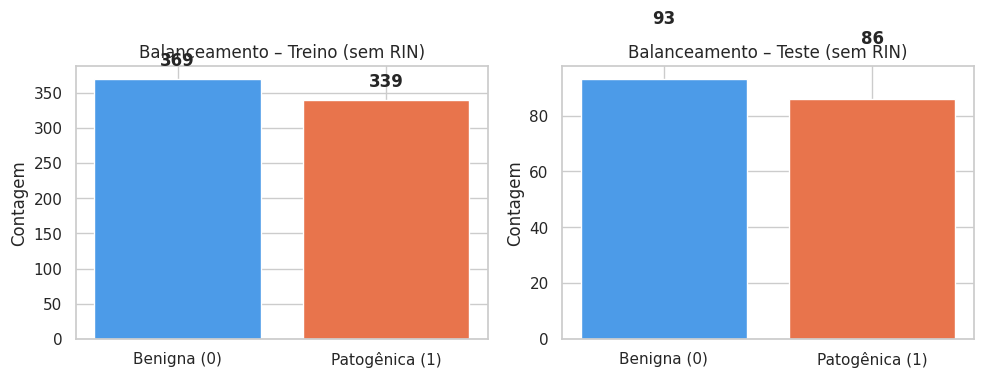

Entropia de Shannon (treino): 0.9987  (esperado: ~0.999)


In [ ]:
# Balanceamento das classes
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, y_) in zip(axes, [('Treino', y_train_sem), ('Teste', y_test_sem)]):
    counts = y_.value_counts()
    ax.bar(['Benigna (0)', 'Patogênica (1)'], counts.values, color=['#4C9BE8', '#E8744C'])
    ax.set_title(f'Balanceamento – {name} (sem RIN)')
    ax.set_ylabel('Contagem')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

from scipy.stats import entropy
entropia = entropy(y_train_sem.value_counts(normalize=True), base=2)
print(f'Entropia de Shannon (treino): {entropia:.4f}  (esperado: ~0.999)')


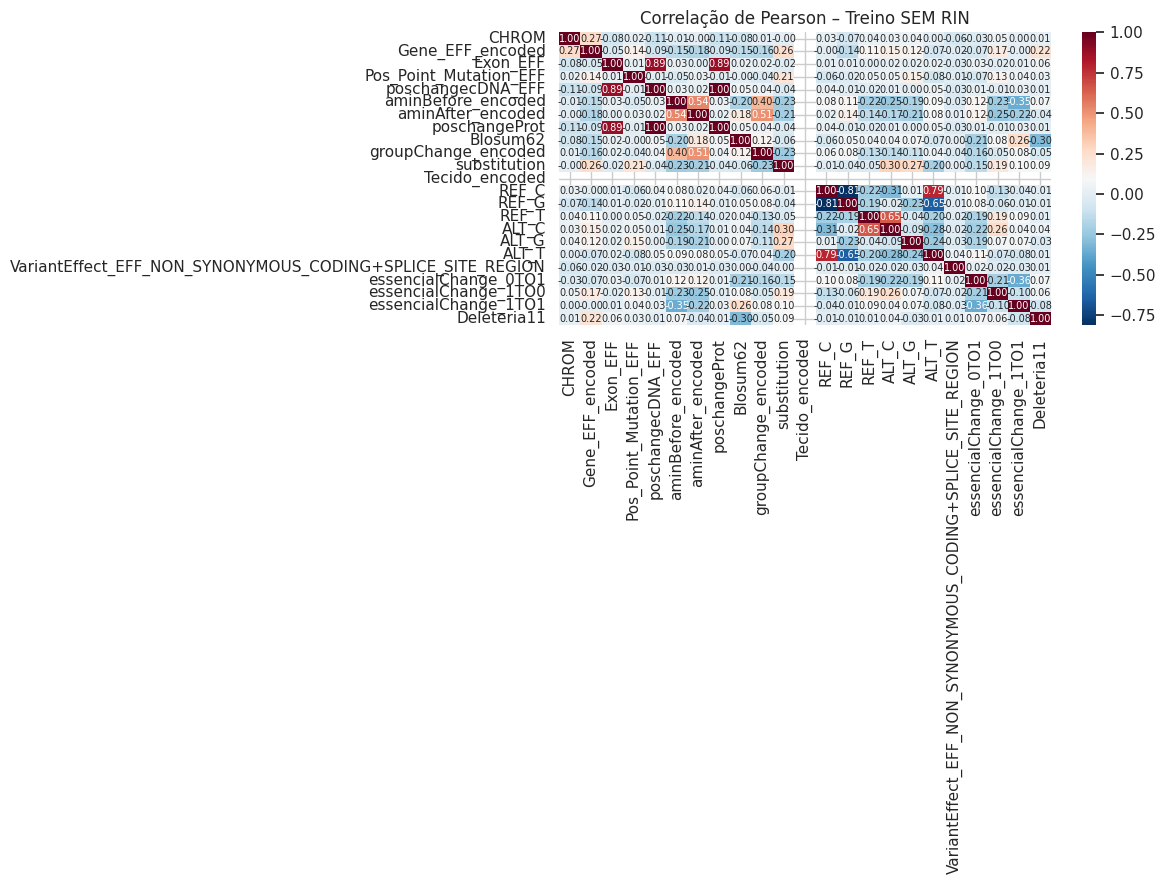


Correlação com o rótulo (ordenado):


,Deleteria11
Gene_EFF_encoded,0.221400
substitution,0.090087
essencialChange_0TO1,0.072965
aminBefore_encoded,0.066924
Exon_EFF,0.056209
essencialChange_1TO0,0.056063
ALT_C,0.040370
Pos_Point_Mutation_EFF,0.033882
CHROM,0.014340
REF_T,0.009893


In [ ]:
# Mapa de calor – correlação numérica no treino
num_plot_sem = X_train_sem.select_dtypes(include=[np.number]).columns.tolist()
corr_sem = pd.concat([X_train_sem[num_plot_sem], y_train_sem], axis=1).corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_sem, annot=True, fmt='.2f', cmap='RdBu_r', annot_kws={'size': 7})
plt.title('Correlação de Pearson – Treino SEM RIN')
plt.tight_layout()
plt.show()

print('\nCorrelação com o rótulo (ordenado):')
display(corr_sem[ROTULO].drop(ROTULO).sort_values(ascending=False).to_frame())

In [ ]:
# Remoção das colunas que possuem mais de 0.75 de correlação
# limite da correlação
limite = 0.75
# pegar apenas o triângulo superior da matriz para evitar remover colunas com correlção entre si mesmas ou seja com valor 1.0
# e não checar o mesmo par duas vezes
triangulo_superior = corr_sem.where(np.triu(np.ones(corr_sem.shape), k=1).astype(bool))
# identificando colunas para remover
colunas_para_remover = [coluna for coluna in triangulo_superior.columns if any(triangulo_superior[coluna] > limite)]
print(f'Colunas para remover: {colunas_para_remover}')
# verificando as correlações dessas colunas
correlacoes_removidas = corr_sem[colunas_para_remover]
display(correlacoes_removidas.style.highlight_between(left=0.75, right=1.0, color='red'))
# Removendo as 2 colunas com maior correlação
X_train_sem.drop(columns=['poschangecDNA_EFF'], inplace=True)
X_test_sem.drop(columns=['poschangecDNA_EFF'], inplace=True)
X_train_sem.drop(columns=['poschangeProt'], inplace=True)
X_test_sem.drop(columns=['poschangeProt'], inplace=True)


Colunas para remover: ['poschangecDNA_EFF', 'poschangeProt', 'ALT_T']


,poschangecDNA_EFF,poschangeProt,ALT_T
CHROM,-0.105224,-0.105234,0.004179
Gene_EFF_encoded,-0.088719,-0.088798,-0.067718
Exon_EFF,0.885758,0.885748,0.016636
Pos_Point_Mutation_EFF,-0.005735,-0.006292,-0.075882
poschangecDNA_EFF,1.000000,1.000000,0.045532
aminBefore_encoded,0.033051,0.033080,0.091338
aminAfter_encoded,0.017552,0.017535,0.084864
poschangeProt,1.000000,1.000000,0.045574
Blosum62,0.054065,0.054065,-0.066394
groupChange_encoded,0.040436,0.040456,0.044508


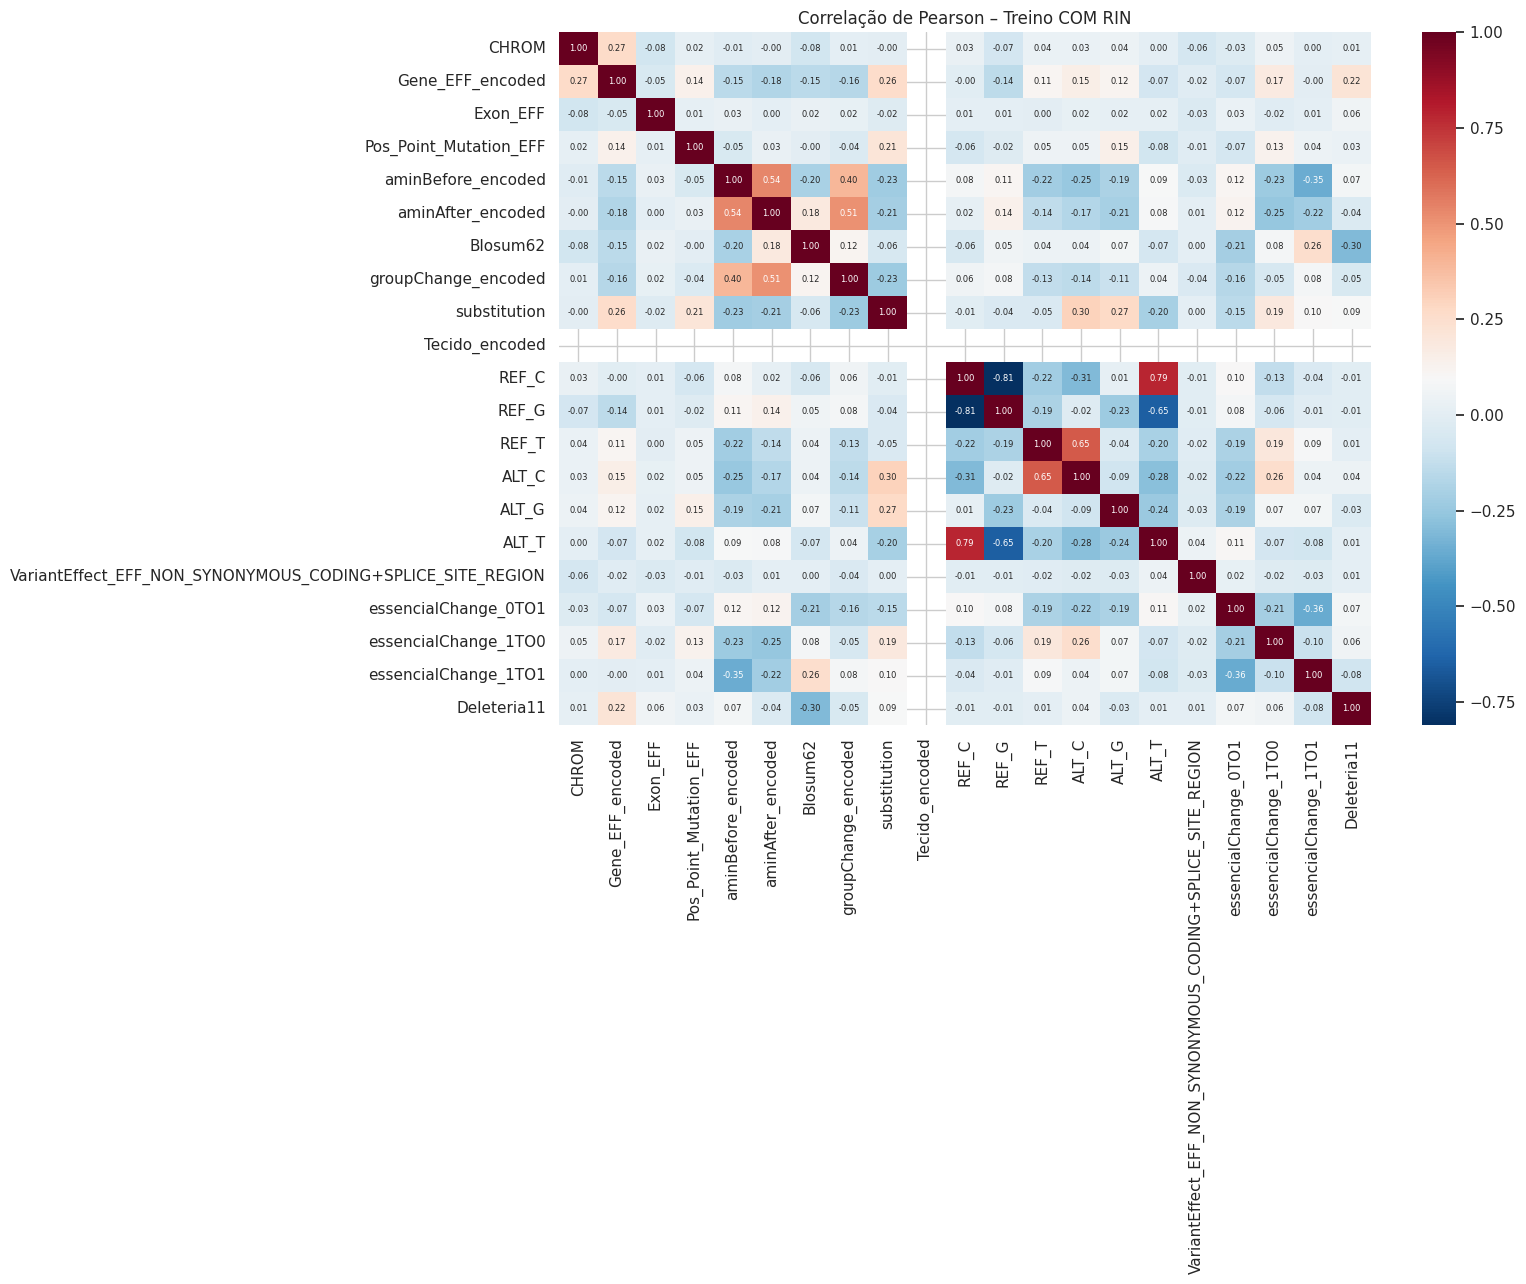


Correlação com o rótulo (ordenado):


,Deleteria11
Gene_EFF_encoded,0.221400
substitution,0.090087
essencialChange_0TO1,0.072965
aminBefore_encoded,0.066924
Exon_EFF,0.056209
essencialChange_1TO0,0.056063
ALT_C,0.040370
Pos_Point_Mutation_EFF,0.033882
CHROM,0.014340
REF_T,0.009893


In [ ]:
# Plotando novamente a matriz de correlação para checar mudanças
num_plot_sem = X_train_sem.select_dtypes(include=[np.number]).columns.tolist()
corr_sem = pd.concat([X_train_sem[num_plot_sem], y_train_sem], axis=1).corr()
plt.figure(figsize=(16, 13))
sns.heatmap(corr_sem, annot=True, fmt='.2f', cmap='RdBu_r', annot_kws={'size': 6})
plt.title('Correlação de Pearson – Treino COM RIN')
plt.tight_layout()
plt.show()

print('\nCorrelação com o rótulo (ordenado):')
display(corr_sem[ROTULO].drop(ROTULO).sort_values(ascending=False).to_frame())

## 3.7 Exportação – Base SEM RIN

In [ ]:
# Reincorporar rótulo
train_sem_final = X_train_sem.copy()
train_sem_final[ROTULO] = y_train_sem.values

test_sem_final = X_test_sem.copy()
test_sem_final[ROTULO] = y_test_sem.values

# Verificação final
assert train_sem_final.isnull().sum().sum() == 0, 'ERRO: valores ausentes no treino!'
assert test_sem_final.isnull().sum().sum()  == 0, 'ERRO: valores ausentes no teste!'
assert train_sem_final[ROTULO].nunique() == 2
assert test_sem_final[ROTULO].nunique()  == 2

print('=' * 60)
print('RESUMO FINAL – BASE SEM RIN')
print('=' * 60)
print(f'Treino : {train_sem_final.shape}  (esperado: ~20.043 x 23)')
print(f'Teste  : {test_sem_final.shape}   (esperado:  5.023 x 23)')
print(f'\nAtributos: {list(train_sem_final.drop(columns=[ROTULO]).columns)}')

# Salvar
path_train_sem = f'{OUTPUT_DIR}/train_sem_rin.csv'
path_test_sem  = f'{OUTPUT_DIR}/test_sem_rin.csv'
train_sem_final.to_csv(path_train_sem, sep='\t', index=False)
test_sem_final.to_csv(path_test_sem,   sep='\t', index=False)
print(f'\nSalvo: {path_train_sem}')
print(f'Salvo: {path_test_sem}')


RESUMO FINAL – BASE SEM RIN
Treino : (708, 21)  (esperado: ~20.043 x 23)
Teste  : (179, 21)   (esperado:  5.023 x 23)

Atributos: ['CHROM', 'Gene_EFF_encoded', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'aminBefore_encoded', 'aminAfter_encoded', 'Blosum62', 'groupChange_encoded', 'substitution', 'Tecido_encoded', 'REF_C', 'REF_G', 'REF_T', 'ALT_C', 'ALT_G', 'ALT_T', 'VariantEffect_EFF_NON_SYNONYMOUS_CODING+SPLICE_SITE_REGION', 'essencialChange_0TO1', 'essencialChange_1TO0', 'essencialChange_1TO1']

Salvo: /content/drive/MyDrive/Bioinfo/Bases/train_sem_rin.csv
Salvo: /content/drive/MyDrive/Bioinfo/Bases/test_sem_rin.csv


# 4. Experimento 2 – Base COM RIN

Nesta seção, executamos o **Experimento 2**, utilizando a base de dados configurada como **COM RIN**. O objetivo é aplicar o pipeline de pré-processamento padronizado para transformar os dados brutos em uma matriz pronta para os algoritmos de Aprendizagem de Máquina, resultando na expansão de **30 atributos brutos para 37 atributos finais**, conforme detalhado na **Seção 4.4.2 da Tese**.

Mesmo pipeline da Seção 3, com o conjunto ampliado de colunas RIN.


## 4.1 Seleção de colunas e Split treino / teste

In [ ]:
cols_com        = [c for c in COLUNAS_COM_RIN if c in df_clean.columns]
colunas_rin_excl = [c for c in COLUNAS_COM_RIN
                    if c not in COLUNAS_SEM_RIN and c in df_clean.columns]

df_com_rin = (df_clean[cols_com]
              .dropna(subset=[ROTULO])
              .dropna(subset=colunas_rin_excl, how='all')
              .copy())

print(f'Base com RIN: {df_com_rin.shape}')
print(f'Distribuição do rótulo:\n{df_com_rin[ROTULO].value_counts()}')


Base com RIN: (891, 31)
Distribuição do rótulo:
Deleteria11
1    464
0    427
Name: count, dtype: int64


In [ ]:
train_com, test_com = train_test_split(
    df_com_rin,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df_com_rin[ROTULO]
)

print('─' * 50)
print(f'Treino : {train_com.shape}  (esperado: ~20.092 x 30)')
print(f'Teste  : {test_com.shape}   (esperado:  5.023 x 30)')
print()
print('Distribuição do rótulo no treino:')
print(train_com[ROTULO].value_counts(normalize=True).round(4))
print('Distribuição do rótulo no teste:')
print(test_com[ROTULO].value_counts(normalize=True).round(4))


──────────────────────────────────────────────────
Treino : (712, 31)  (esperado: ~20.092 x 30)
Teste  : (179, 31)   (esperado:  5.023 x 30)

Distribuição do rótulo no treino:
Deleteria11
1    0.5211
0    0.4789
Name: proportion, dtype: float64
Distribuição do rótulo no teste:
Deleteria11
1    0.5196
0    0.4804
Name: proportion, dtype: float64


In [ ]:
X_train_com = train_com.drop(columns=[ROTULO]).copy()
y_train_com = train_com[ROTULO].copy()
X_test_com  = test_com.drop(columns=[ROTULO]).copy()
y_test_com  = test_com[ROTULO].copy()


## 4.2 Remoção de Outliers com LocalOutlierFactor

`fit_predict` aplicado **apenas no treino**.


In [ ]:
num_cols_com = X_train_com.select_dtypes(include=[np.number]).columns.tolist()
print(f'Colunas numéricas usadas no LOF ({len(num_cols_com)}): {num_cols_com}')

X_train_com_num = X_train_com[num_cols_com].fillna(
    X_train_com[num_cols_com].median()
)

lof_com  = LocalOutlierFactor(n_neighbors=20, contamination='auto')
pred_com = lof_com.fit_predict(X_train_com_num)

mask_com = pred_com == 1
X_train_com = X_train_com[mask_com].copy()
y_train_com = y_train_com[mask_com].copy()

print(f'\nTreino original  : {train_com.shape[0]:,} registros')
print(f'Treino após LOF  : {X_train_com.shape[0]:,} registros')
print(f'Outliers removidos: {(~mask_com).sum():,}  (esperado: ~605, conforme tese)')
print(f'Teste inalterado  : {X_test_com.shape[0]:,} registros')


Colunas numéricas usadas no LOF (21): ['CHROM', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF', 'poschangeProt', 'Blosum62', 'substitution', 'Degree_RING', 'Bfactor_CA_RING', 'triangles_node', 'clusteringCoef_node', 'betweennessWeighted_node', 'Inter_Lig_tot', 'Inter_Res_tot', 'Inter_IAC_Lig_tot', 'Inter_VDW_Lig_tot', 'Inter_VDW_Res_tot', 'Inter_HBOND_Res_tot', 'Inter_PIPISTACK_Res_tot', 'Inter_IONIC_Res_tot', 'Inter_PICATION_Res_tot']

Treino original  : 712 registros
Treino após LOF  : 646 registros
Outliers removidos: 66  (esperado: ~605, conforme tese)
Teste inalterado  : 179 registros


## 4.3 Encoding de Atributos Categóricos

`fit` somente no treino; `transform` em treino e teste.


In [ ]:
high_card_com = [c for c in HIGH_CARD if c in X_train_com.columns]
low_card_com  = [c for c in LOW_CARD  if c in X_train_com.columns]
print('Frequency Encoding:', high_card_com)
print('One-Hot Encoding   :', low_card_com)


Frequency Encoding: ['Gene_EFF', 'aminBefore', 'aminAfter', 'groupChange', 'Tecido']
One-Hot Encoding   : ['REF', 'ALT', 'VariantEffect_EFF', 'essencialChange']


In [ ]:
# ── Frequency Encoding ───────────────────────────────────────────────────────
freq_enc_com = ce.CountEncoder(cols=high_card_com, normalize=True)
freq_enc_com.fit(X_train_com[high_card_com])

X_train_com[high_card_com] = freq_enc_com.transform(X_train_com[high_card_com])
X_test_com[high_card_com]  = freq_enc_com.transform(X_test_com[high_card_com])

rename_com = {c: f'{c}_encoded' for c in high_card_com}
X_train_com.rename(columns=rename_com, inplace=True)
X_test_com.rename(columns=rename_com,  inplace=True)

# ── One-Hot Encoding ─────────────────────────────────────────────────────────
ohe_com = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
ohe_com.fit(X_train_com[low_card_com])

ohe_cols_com = ohe_com.get_feature_names_out(low_card_com)
X_train_com[ohe_cols_com] = ohe_com.transform(X_train_com[low_card_com])
X_test_com[ohe_cols_com]  = ohe_com.transform(X_test_com[low_card_com])

X_train_com.drop(columns=low_card_com, inplace=True)
X_test_com.drop(columns=low_card_com,  inplace=True)

print(f'Shape treino com RIN: {X_train_com.shape}  (esperado: ~19.487 x 37, conforme tese)')
print(f'Shape teste  com RIN: {X_test_com.shape}   (esperado:  5.023 x 37)')
print(f'\nColunas finais: {list(X_train_com.columns)}')


Shape treino com RIN: (646, 36)  (esperado: ~19.487 x 37, conforme tese)
Shape teste  com RIN: (179, 36)   (esperado:  5.023 x 37)

Colunas finais: ['CHROM', 'Gene_EFF_encoded', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF', 'aminBefore_encoded', 'aminAfter_encoded', 'poschangeProt', 'Blosum62', 'groupChange_encoded', 'substitution', 'Degree_RING', 'Bfactor_CA_RING', 'triangles_node', 'clusteringCoef_node', 'betweennessWeighted_node', 'Inter_Lig_tot', 'Inter_Res_tot', 'Inter_IAC_Lig_tot', 'Inter_VDW_Lig_tot', 'Inter_VDW_Res_tot', 'Inter_HBOND_Res_tot', 'Inter_PIPISTACK_Res_tot', 'Inter_IONIC_Res_tot', 'Inter_PICATION_Res_tot', 'Tecido_encoded', 'REF_C', 'REF_G', 'REF_T', 'ALT_C', 'ALT_G', 'ALT_T', 'VariantEffect_EFF_NON_SYNONYMOUS_CODING+SPLICE_SITE_REGION', 'essencialChange_0TO1', 'essencialChange_1TO0', 'essencialChange_1TO1']


## 4.4 Imputação de Valores Ausentes

In [ ]:
num_c_com = X_train_com.select_dtypes(include=[np.number]).columns.tolist()

miss_train_c = X_train_com[num_c_com].isnull().sum().sum()
miss_test_c  = X_test_com[num_c_com].isnull().sum().sum()
print(f'Valores ausentes – treino: {miss_train_c}  |  teste: {miss_test_c}')

if miss_train_c > 0 or miss_test_c > 0:
    imp_com = SimpleImputer(strategy='median')
    X_train_com[num_c_com] = imp_com.fit_transform(X_train_com[num_c_com])
    X_test_com[num_c_com]  = imp_com.transform(X_test_com[num_c_com])
    print('Imputação pela mediana aplicada.')
else:
    print('Nenhum valor ausente – imputação não necessária.')


Valores ausentes – treino: 0  |  teste: 0
Nenhum valor ausente – imputação não necessária.


## 4.5 Normalização com MinMaxScaler

In [ ]:
num_final_com = X_train_com.select_dtypes(include=[np.number]).columns.tolist()

scaler_com = MinMaxScaler()
X_train_com[num_final_com] = scaler_com.fit_transform(X_train_com[num_final_com])
X_test_com[num_final_com]  = scaler_com.transform(X_test_com[num_final_com])

print('MinMaxScaler aplicado.')
print('\nTreino – resumo estatístico (valores devem estar em [0, 1]):')
display(X_train_com[num_final_com].describe().round(4))


MinMaxScaler aplicado.

Treino – resumo estatístico (valores devem estar em [0, 1]):


,CHROM,Gene_EFF_encoded,Exon_EFF,Pos_Point_Mutation_EFF,poschangecDNA_EFF,aminBefore_encoded,aminAfter_encoded,poschangeProt,Blosum62,groupChange_encoded,substitution,Degree_RING,Bfactor_CA_RING,triangles_node,clusteringCoef_node,betweennessWeighted_node,Inter_Lig_tot,Inter_Res_tot,Inter_IAC_Lig_tot,Inter_VDW_Lig_tot,Inter_VDW_Res_tot,Inter_HBOND_Res_tot,Inter_PIPISTACK_Res_tot,Inter_IONIC_Res_tot,Inter_PICATION_Res_tot,Tecido_encoded,REF_C,REF_G,REF_T,ALT_C,ALT_G,ALT_T,VariantEffect_EFF_NON_SYNONYMOUS_CODING+SPLICE_SITE_REGION,essencialChange_0TO1,essencialChange_1TO0,essencialChange_1TO1
count,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0,646.0000,646.0000,646.0000,646.0000,646.0000,646.0,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000,646.0000
mean,0.4157,0.0628,0.1370,0.2763,0.1749,0.4462,0.5390,0.1748,0.4474,0.5661,0.1533,0.0424,0.1954,0.0861,0.0463,0.0277,0.0157,0.2059,0.0157,0.0,0.1505,0.2747,0.0088,0.0480,0.0054,0.0,0.4830,0.4133,0.0495,0.0975,0.0681,0.4334,0.0418,0.4226,0.0542,0.1533
std,0.3153,0.2088,0.1285,0.2878,0.1691,0.3884,0.2648,0.1691,0.2851,0.3386,0.3605,0.0758,0.1413,0.1385,0.1027,0.0607,0.0725,0.1452,0.0725,0.0,0.1646,0.1781,0.0725,0.1551,0.0588,0.0,0.5001,0.4928,0.2172,0.2969,0.2521,0.4959,0.2003,0.4944,0.2265,0.3605
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0952,0.0000,0.0556,0.0000,0.0680,0.1667,0.3896,0.0679,0.1667,0.3707,0.0000,0.0112,0.0918,0.0000,0.0000,0.0003,0.0000,0.1071,0.0000,0.0,0.0476,0.1111,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.4286,0.0000,0.1111,0.5000,0.1230,0.2843,0.5195,0.1228,0.5000,0.4224,0.0000,0.0223,0.1661,0.0000,0.0000,0.0092,0.0000,0.1786,0.0000,0.0,0.0952,0.2222,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.7143,0.0345,0.1852,0.5000,0.2129,1.0000,0.6104,0.2128,0.6667,0.9569,0.0000,0.0447,0.2666,0.1429,0.0576,0.0329,0.0000,0.2857,0.0000,0.0,0.1905,0.4167,0.0000,0.0000,0.0000,0.0,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


## 4.6 EDA Rápida – Base COM RIN

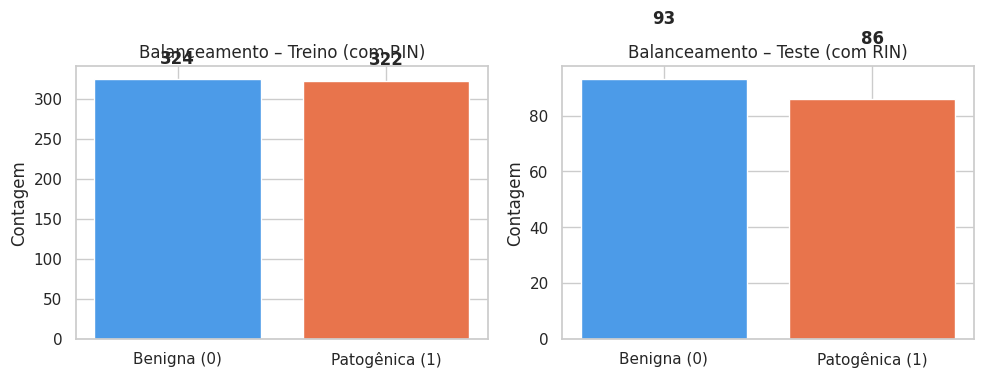

Entropia de Shannon (treino): 1.0000  (esperado: ~0.999)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, y_) in zip(axes, [('Treino', y_train_com), ('Teste', y_test_com)]):
    counts = y_.value_counts()
    ax.bar(['Benigna (0)', 'Patogênica (1)'], counts.values, color=['#4C9BE8', '#E8744C'])
    ax.set_title(f'Balanceamento – {name} (com RIN)')
    ax.set_ylabel('Contagem')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

entropia_com = entropy(y_train_com.value_counts(normalize=True), base=2)
print(f'Entropia de Shannon (treino): {entropia_com:.4f}  (esperado: ~0.999)')


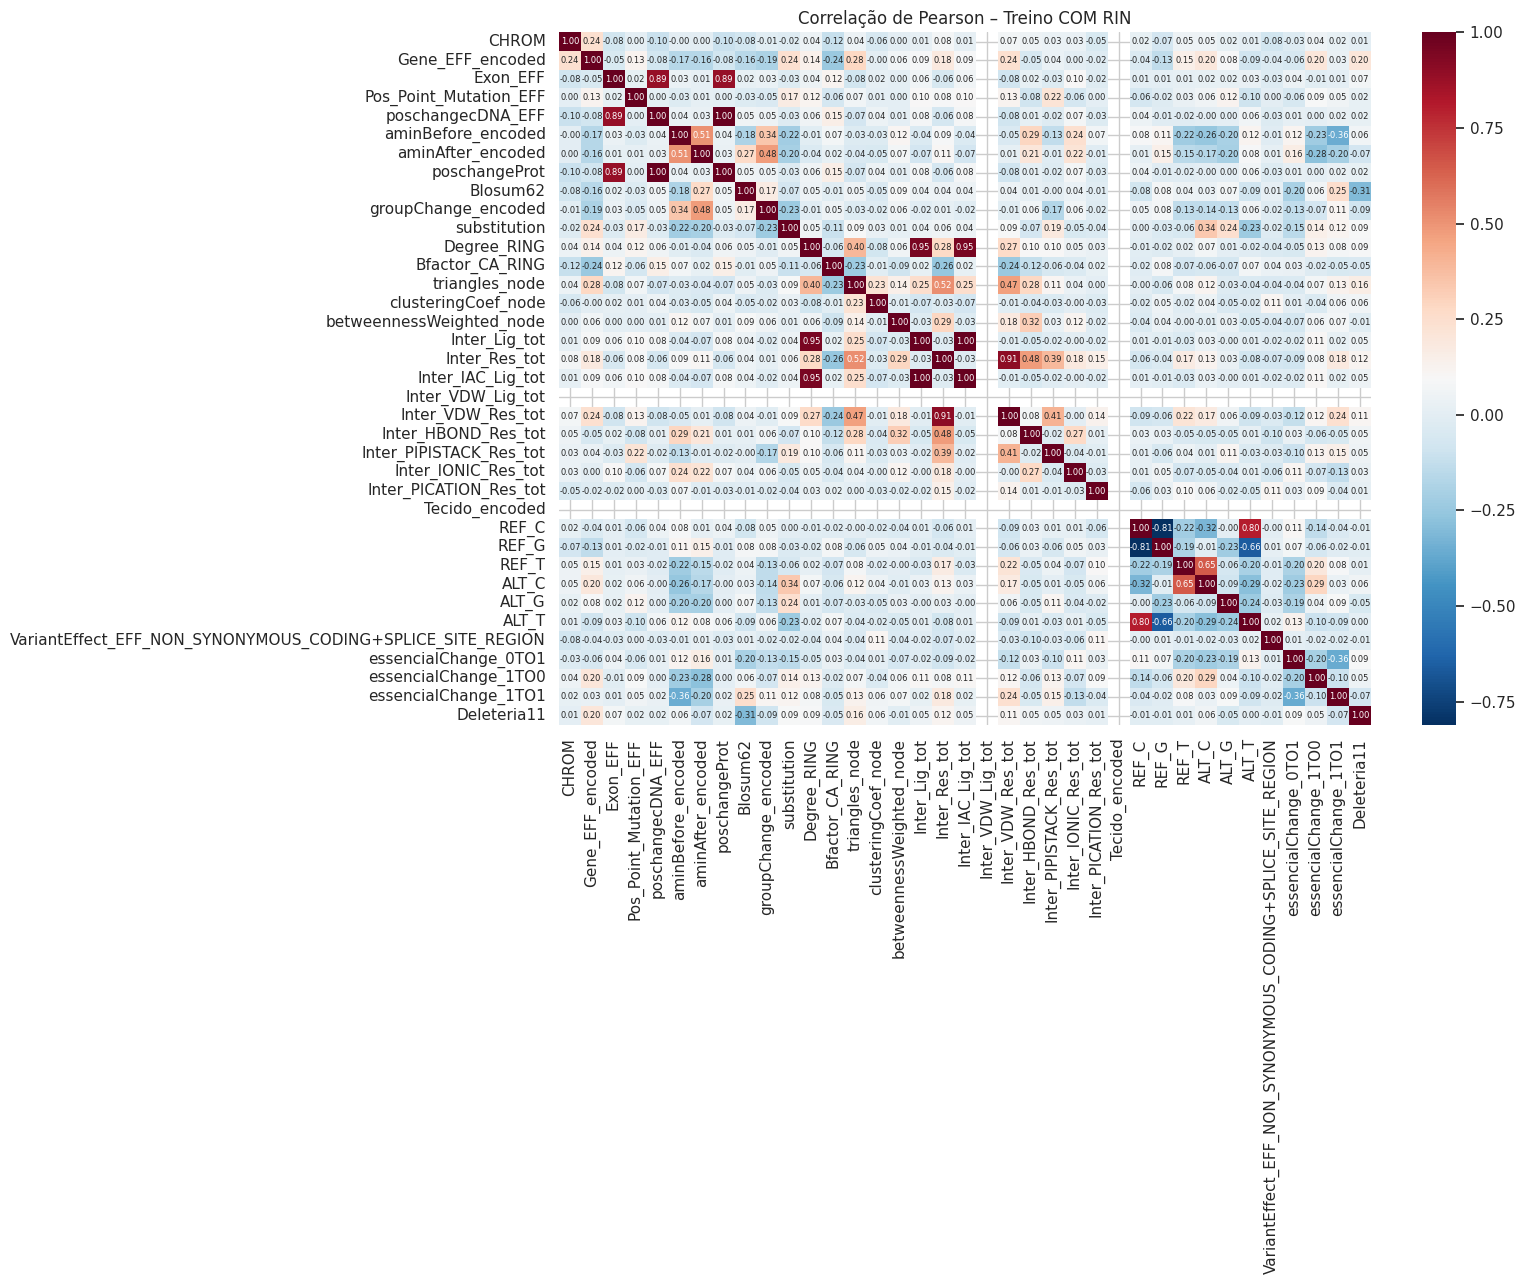


Correlação com o rótulo (ordenado):


,Deleteria11
Gene_EFF_encoded,0.204239
triangles_node,0.160309
Inter_Res_tot,0.121742
Inter_VDW_Res_tot,0.112778
substitution,0.088925
essencialChange_0TO1,0.088231
Degree_RING,0.085824
Exon_EFF,0.068598
aminBefore_encoded,0.060889
clusteringCoef_node,0.059150


In [ ]:
num_plot_com = X_train_com.select_dtypes(include=[np.number]).columns.tolist()
corr_com = pd.concat([X_train_com[num_plot_com], y_train_com], axis=1).corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr_com, annot=True, fmt='.2f', cmap='RdBu_r', annot_kws={'size': 6})
plt.title('Correlação de Pearson – Treino COM RIN')
plt.tight_layout()
plt.show()

print('\nCorrelação com o rótulo (ordenado):')
display(corr_com[ROTULO].drop(ROTULO).sort_values(ascending=False).to_frame())


In [ ]:
# Remoção das colunas que possuem mais de 0.75 de correlação
# limite da correlação
limite = 0.75
# pegar apenas o triângulo superior da matriz para evitar remover colunas com correlção entre si mesmas ou seja com valor 1.0
# e não checar o mesmo par duas vezes
triangulo_superior = corr_com.where(np.triu(np.ones(corr_com.shape), k=1).astype(bool))
# identificando colunas para remover
colunas_para_remover = [coluna for coluna in triangulo_superior.columns if any(triangulo_superior[coluna] > limite)]
print(f'Colunas para remover: {colunas_para_remover}')
# verificando as correlações dessas colunas
correlacoes_removidas = corr_com[colunas_para_remover]
display(correlacoes_removidas.style.highlight_between(left=0.75, right=1.0, color='red'))
# Removendo as 5 colunas com maior correlação
X_train_com.drop(columns=['Inter_Lig_tot'], inplace=True)
X_test_com.drop(columns=['Inter_Lig_tot'], inplace=True)
X_train_com.drop(columns=['Inter_IAC_Lig_tot'], inplace=True)
X_test_com.drop(columns=['Inter_IAC_Lig_tot'], inplace=True)
X_train_com.drop(columns=['Inter_VDW_Res_tot'], inplace=True)
X_test_com.drop(columns=['Inter_VDW_Res_tot'], inplace=True)
X_train_com.drop(columns=['poschangecDNA_EFF'], inplace=True)
X_test_com.drop(columns=['poschangecDNA_EFF'], inplace=True)
X_train_com.drop(columns=['poschangeProt'], inplace=True)
X_test_com.drop(columns=['poschangeProt'], inplace=True)


Colunas para remover: ['poschangecDNA_EFF', 'poschangeProt', 'Inter_Lig_tot', 'Inter_IAC_Lig_tot', 'Inter_VDW_Res_tot', 'ALT_T']


,poschangecDNA_EFF,poschangeProt,Inter_Lig_tot,Inter_IAC_Lig_tot,Inter_VDW_Res_tot,ALT_T
CHROM,-0.104277,-0.104278,0.014917,0.014917,0.067873,0.009169
Gene_EFF_encoded,-0.080897,-0.080964,0.086072,0.086072,0.239911,-0.088650
Exon_EFF,0.886210,0.886203,0.060147,0.060147,-0.082709,0.027115
Pos_Point_Mutation_EFF,0.004078,0.003547,0.095349,0.095349,0.125842,-0.096330
poschangecDNA_EFF,1.000000,1.000000,0.079006,0.079006,-0.082835,0.060527
aminBefore_encoded,0.036618,0.036636,-0.036206,-0.036206,-0.046749,0.115728
aminAfter_encoded,0.027123,0.027116,-0.071427,-0.071427,0.011279,0.082877
poschangeProt,1.000000,1.000000,0.078955,0.078955,-0.082902,0.060578
Blosum62,0.053215,0.053230,0.039444,0.039444,0.043212,-0.086948
groupChange_encoded,0.050252,0.050276,-0.018235,-0.018235,-0.008909,0.058238


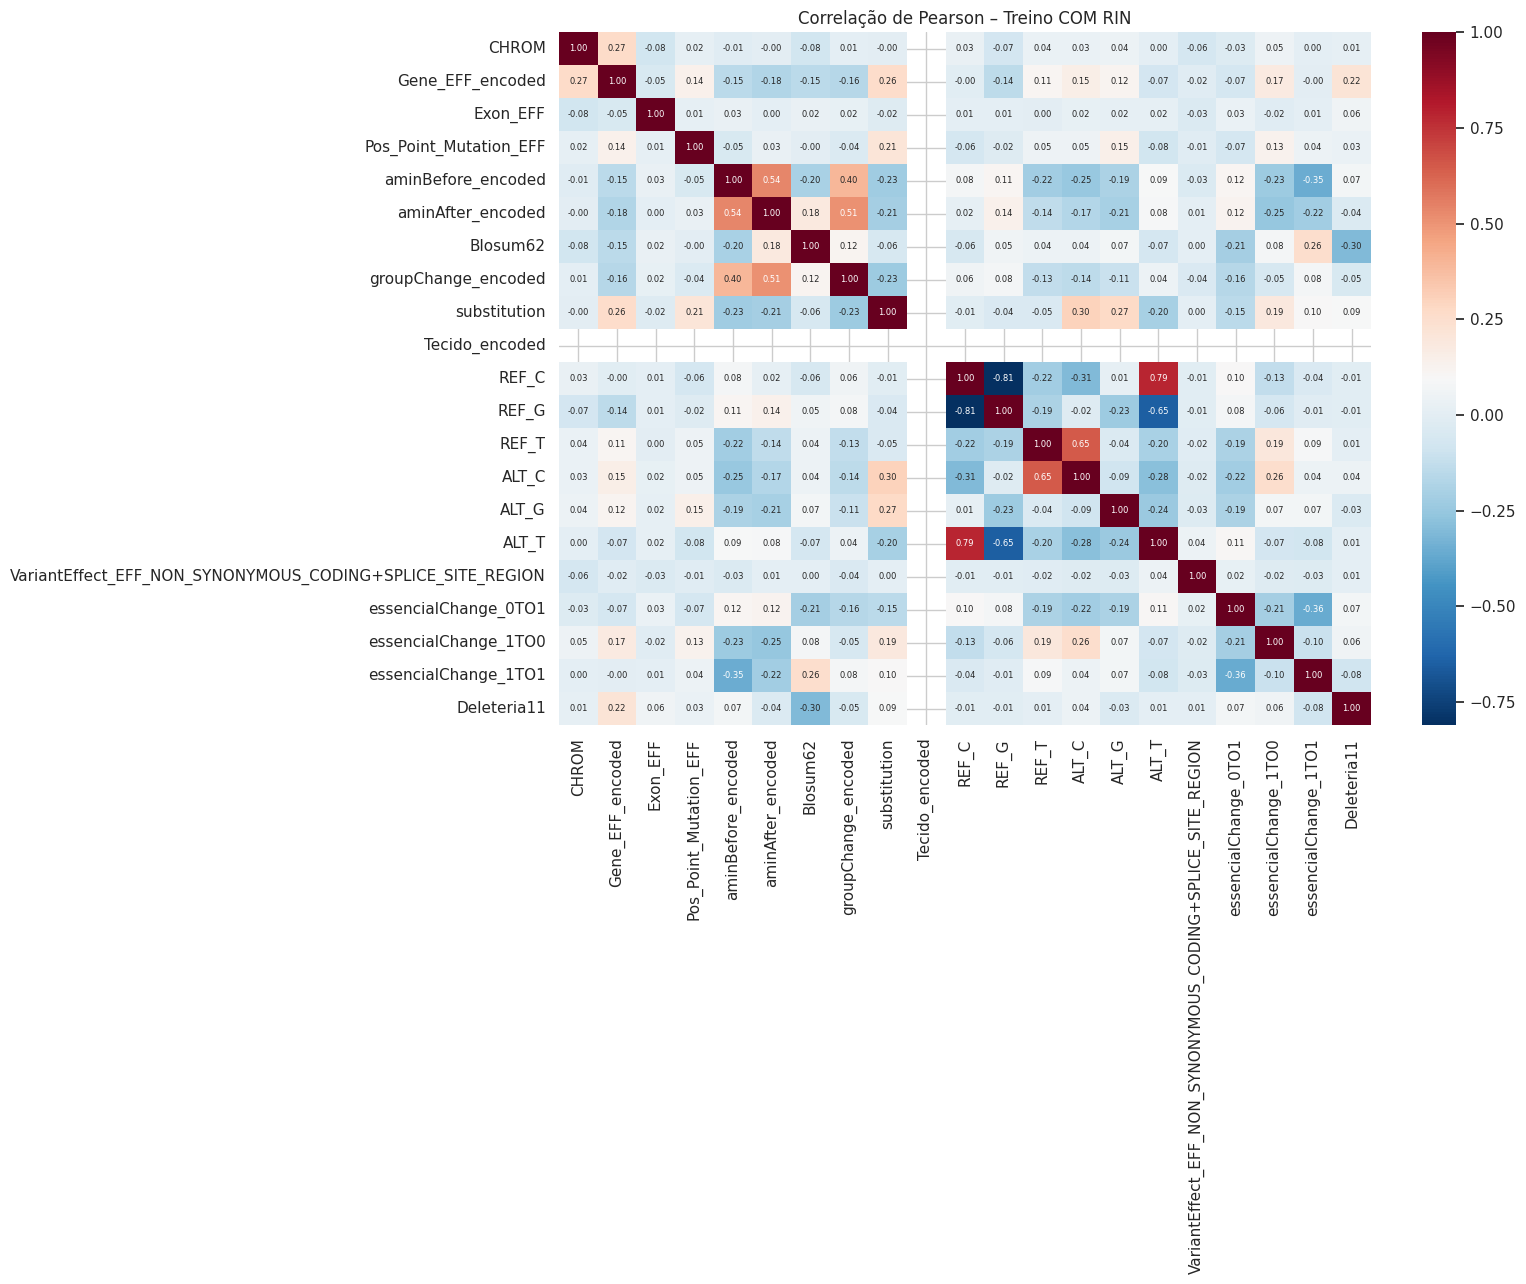


Correlação com o rótulo (ordenado):


,Deleteria11
Gene_EFF_encoded,0.221400
substitution,0.090087
essencialChange_0TO1,0.072965
aminBefore_encoded,0.066924
Exon_EFF,0.056209
essencialChange_1TO0,0.056063
ALT_C,0.040370
Pos_Point_Mutation_EFF,0.033882
CHROM,0.014340
REF_T,0.009893


In [ ]:
# Plotando novamente a matriz de correlação para checar mudanças
num_plot_sem = X_train_sem.select_dtypes(include=[np.number]).columns.tolist()
corr_com = pd.concat([X_train_sem[num_plot_sem], y_train_sem], axis=1).corr()
plt.figure(figsize=(16, 13))
sns.heatmap(corr_com, annot=True, fmt='.2f', cmap='RdBu_r', annot_kws={'size': 6})
plt.title('Correlação de Pearson – Treino COM RIN')
plt.tight_layout()
plt.show()

print('\nCorrelação com o rótulo (ordenado):')
display(corr_com[ROTULO].drop(ROTULO).sort_values(ascending=False).to_frame())

## 4.7 Exportação – Base COM RIN

In [ ]:
train_com_final = X_train_com.copy()
train_com_final[ROTULO] = y_train_com.values

test_com_final = X_test_com.copy()
test_com_final[ROTULO] = y_test_com.values

assert train_com_final.isnull().sum().sum() == 0, 'ERRO: valores ausentes no treino!'
assert test_com_final.isnull().sum().sum()  == 0, 'ERRO: valores ausentes no teste!'
assert train_com_final[ROTULO].nunique() == 2
assert test_com_final[ROTULO].nunique()  == 2

print('=' * 60)
print('RESUMO FINAL – BASE COM RIN')
print('=' * 60)
print(f'Treino : {train_com_final.shape}  (esperado: ~19.487 x 37)')
print(f'Teste  : {test_com_final.shape}   (esperado:  5.023 x 37)')
print(f'\nAtributos: {list(train_com_final.drop(columns=[ROTULO]).columns)}')

path_train_com = f'{OUTPUT_DIR}/train_com_rin.csv'
path_test_com  = f'{OUTPUT_DIR}/test_com_rin.csv'
train_com_final.to_csv(path_train_com, sep='\t', index=False)
test_com_final.to_csv(path_test_com,   sep='\t', index=False)
print(f'\nSalvo: {path_train_com}')
print(f'Salvo: {path_test_com}')


RESUMO FINAL – BASE COM RIN
Treino : (646, 32)  (esperado: ~19.487 x 37)
Teste  : (179, 32)   (esperado:  5.023 x 37)

Atributos: ['CHROM', 'Gene_EFF_encoded', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'aminBefore_encoded', 'aminAfter_encoded', 'Blosum62', 'groupChange_encoded', 'substitution', 'Degree_RING', 'Bfactor_CA_RING', 'triangles_node', 'clusteringCoef_node', 'betweennessWeighted_node', 'Inter_Res_tot', 'Inter_VDW_Lig_tot', 'Inter_HBOND_Res_tot', 'Inter_PIPISTACK_Res_tot', 'Inter_IONIC_Res_tot', 'Inter_PICATION_Res_tot', 'Tecido_encoded', 'REF_C', 'REF_G', 'REF_T', 'ALT_C', 'ALT_G', 'ALT_T', 'VariantEffect_EFF_NON_SYNONYMOUS_CODING+SPLICE_SITE_REGION', 'essencialChange_0TO1', 'essencialChange_1TO0', 'essencialChange_1TO1']

Salvo: /content/drive/MyDrive/Bioinfo/Bases/train_com_rin.csv
Salvo: /content/drive/MyDrive/Bioinfo/Bases/test_com_rin.csv


# 5. Resumo Geral e Guia para Cross-Validation
Esta seção consolida o fechamento da etapa de engenharia de recursos e pré-processamento. Abaixo, apresentamos o mapeamento final das bases de dados exportadas para o Google Drive e estabelecemos as diretrizes metodológicas para a fase de modelagem e validação.

In [ ]:
print('=' * 65)
print('RESUMO GERAL – BASES PRONTAS PARA ML')
print('=' * 65)
print()
print('EXPERIMENTO 1 – SEM RIN')
print(f'  Treino : {train_sem_final.shape}  → {path_train_sem}')
print(f'  Teste  : {test_sem_final.shape}   → {path_test_sem}')
print()
print('EXPERIMENTO 2 – COM RIN')
print(f'  Treino : {train_com_final.shape}  → {path_train_com}')
print(f'  Teste  : {test_com_final.shape}   → {path_test_com}')
print()
print('─' * 65)
print('Garantias anti-leakage:')
print('  ✓ Split feito ANTES de qualquer transformação')
print('  ✓ LOF: fit_predict apenas no treino')
print('  ✓ Frequency Encoding: fit apenas no treino')
print('  ✓ One-Hot Encoding:   fit apenas no treino')
print('  ✓ MinMaxScaler:       fit apenas no treino')
print('  ✓ Teste nunca influenciou nenhum fit')


RESUMO GERAL – BASES PRONTAS PARA ML

EXPERIMENTO 1 – SEM RIN
  Treino : (708, 21)  → /content/drive/MyDrive/Bioinfo/Bases/train_sem_rin.csv
  Teste  : (179, 21)   → /content/drive/MyDrive/Bioinfo/Bases/test_sem_rin.csv

EXPERIMENTO 2 – COM RIN
  Treino : (646, 32)  → /content/drive/MyDrive/Bioinfo/Bases/train_com_rin.csv
  Teste  : (179, 32)   → /content/drive/MyDrive/Bioinfo/Bases/test_com_rin.csv

─────────────────────────────────────────────────────────────────
Garantias anti-leakage:
  ✓ Split feito ANTES de qualquer transformação
  ✓ LOF: fit_predict apenas no treino
  ✓ Frequency Encoding: fit apenas no treino
  ✓ One-Hot Encoding:   fit apenas no treino
  ✓ MinMaxScaler:       fit apenas no treino
  ✓ Teste nunca influenciou nenhum fit
